# 📊 텔코 고객 이탈 예측 모델링

> BigQuery feature mart 기반으로 이탈 예측 모델을 학습하고,
> 피처 선택 / PCA / SMOTE 등 다양한 기법을 비교 실험합니다.

---

## 0. 환경 설정 및 데이터 로드

> Google Colab 인증 후 BigQuery에서 feature_mart 테이블을 불러옵니다.


In [7]:
from google.colab import auth
auth.authenticate_user()
print('인증 완료')

인증 완료


In [8]:
!pip install -q pandas-gbq scikit-learn xgboost seaborn matplotlib

In [9]:
import pandas as pd
import numpy as np
from pandas_gbq import read_gbq

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

import seaborn as sns
import matplotlib.pyplot as plt


In [10]:
query = """
SELECT *
FROM `telco-490702.telco.feature_mart`
"""

df = read_gbq(query, project_id="telco-490702")
df.head()


Downloading: 100%|██████████|


,CustomerID,Gender,Age,SeniorCitizen,Married,Dependents,TenureInMonths,Offer,PhoneService,InternetService,...,IsLongTermCustomer,IsSeniorAgeGroup,ChargeToMonthlyRatio,AvgChargePerMonth,RevenueToCltvRatio,MonthlyChargeBand,SatisfactionBand,PopulationBand,ContractRiskLevel,IsAutoPayment
0,5192-EBGOV,Female,68,True,False,False,1,None,True,True,...,0,1,1.000000000,85.700000000,0.026900000,High,Low,Low,High Risk,0
1,0151-ONTOV,Female,43,False,False,False,1,Offer E,True,True,...,0,0,1.000000000,70.900000000,0.023400000,High,Low,Low,High Risk,0
2,5923-GXUOC,Male,37,False,False,False,10,None,True,True,...,0,0,10.360000000,108.150000000,0.231400000,High,Low,Low,High Risk,0
3,4210-QFJMF,Female,41,False,False,False,4,Offer E,True,True,...,0,0,4.010000000,79.310000000,0.080700000,High,Low,Low,High Risk,0
4,9564-KCLHR,Male,58,False,False,False,1,None,True,True,...,0,0,1.000000000,51.250000000,0.026500000,Mid,Low,Low,High Risk,0


---

## 1. 데이터 탐색

> 컬럼 구조와 결측치 현황을 파악합니다.

In [11]:
df.info()
df.isnull().sum().sort_values(ascending=False).head(20)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 43 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            7043 non-null   object 
 1   Gender                7043 non-null   object 
 2   Age                   7043 non-null   Int64  
 3   SeniorCitizen         7043 non-null   boolean
 4   Married               7043 non-null   boolean
 5   Dependents            7043 non-null   boolean
 6   TenureInMonths        7043 non-null   Int64  
 7   Offer                 7043 non-null   object 
 8   PhoneService          7043 non-null   boolean
 9   InternetService       7043 non-null   boolean
 10  InternetType          7043 non-null   object 
 11  Contract              7043 non-null   object 
 12  PaymentMethod         7043 non-null   object 
 13  MonthlyCharge         7043 non-null   object 
 14  TotalCharges          7043 non-null   object 
 15  TotalRevenue         

,0
ChurnReason,5174
ChurnCategory,5174
CustomerID,0
SeniorCitizen,0
Married,0
Dependents,0
TenureInMonths,0
Offer,0
PhoneService,0
Gender,0


---

## 2. 타깃 및 제외 컬럼 설정

> 이탈 이후 정보(ChurnCategory, ChurnReason 등)는 데이터 누수 방지를 위해 제거합니다.

In [12]:
target = "ChurnValue"

drop_cols = [
    "CustomerID",
    "ChurnLabel",
    "ChurnCategory",
    "ChurnReason",
    "CustomerStatus",
    "ChurnScore"
]

model_df = df.drop(columns=[col for col in drop_cols if col in df.columns]).copy()
model_df.head()


,Gender,Age,SeniorCitizen,Married,Dependents,TenureInMonths,Offer,PhoneService,InternetService,InternetType,...,IsLongTermCustomer,IsSeniorAgeGroup,ChargeToMonthlyRatio,AvgChargePerMonth,RevenueToCltvRatio,MonthlyChargeBand,SatisfactionBand,PopulationBand,ContractRiskLevel,IsAutoPayment
0,Female,68,True,False,False,1,None,True,True,Fiber Optic,...,0,1,1.000000000,85.700000000,0.026900000,High,Low,Low,High Risk,0
1,Female,43,False,False,False,1,Offer E,True,True,Fiber Optic,...,0,0,1.000000000,70.900000000,0.023400000,High,Low,Low,High Risk,0
2,Male,37,False,False,False,10,None,True,True,Fiber Optic,...,0,0,10.360000000,108.150000000,0.231400000,High,Low,Low,High Risk,0
3,Female,41,False,False,False,4,Offer E,True,True,Fiber Optic,...,0,0,4.010000000,79.310000000,0.080700000,High,Low,Low,High Risk,0
4,Male,58,False,False,False,1,None,True,True,DSL,...,0,0,1.000000000,51.250000000,0.026500000,Mid,Low,Low,High Risk,0


## 3. 전처리 — 숫자형 변환 및 결측치 처리

> 숫자형 컬럼은 중앙값, 범주형 컬럼은 "Unknown"으로 결측치를 채웁니다.

In [13]:
numeric_candidates = [
    "Age", "TenureInMonths", "MonthlyCharge", "TotalCharges", "TotalRevenue",
    "SatisfactionScore", "ChurnValue", "ChurnScore", "CLTV", "Population",
    "TenureYearGroup", "IsLongTermCustomer", "IsSeniorAgeGroup",
    "ChargeToMonthlyRatio", "AvgChargePerMonth", "RevenueToCltvRatio",
    "IsAutoPayment", "Latitude", "Longitude"
]

for col in numeric_candidates:
    if col in model_df.columns:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")


In [14]:
# 결측치 처리입니다. 숫자는 중앙값, 범주는 "Unknown"으로 채웁니다.
for col in model_df.columns:
    if col == target:
        continue
    if model_df[col].dtype in ["int64", "float64", "int32", "float32"]:
        model_df[col] = model_df[col].fillna(model_df[col].median())
    else:
        model_df[col] = model_df[col].fillna("Unknown")



## 4. 입력/타깃 분리 및 원핫인코딩

In [15]:
#입력/타깃 분리 후 원핫인코딩합니다.
X = model_df.drop(columns=[target])
y = model_df[target]

X = pd.get_dummies(X, drop_first=True)

print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts(normalize=True))


X shape: (7043, 1154)
y distribution:
ChurnValue
0    0.73463
1    0.26537
Name: proportion, dtype: Float64


## 5. 학습/테스트 데이터 분리

> 클래스 불균형을 고려해 stratify 옵션으로 분리합니다.

In [16]:
#학습/평가 데이터 분리:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## 6. 모델 학습 — Random Forest (베이스라인)

> 전체 피처로 Random Forest를 먼저 학습해 기준 성능을 확인합니다.

In [17]:
#Random Forest부터 돌리면 안정적입니다.
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]


### 6-1. 성능 평가

In [18]:
#평가
print("F1-score:", f1_score(y_test, rf_pred))
print("ROC-AUC :", roc_auc_score(y_test, rf_pred_proba))
print()
print(classification_report(y_test, rf_pred))


F1-score: 0.8427672955974843
ROC-AUC : 0.9631455217132967

              precision    recall  f1-score   support

         0.0       0.96      0.92      0.94      1035
         1.0       0.80      0.90      0.84       374

    accuracy                           0.91      1409
   macro avg       0.88      0.91      0.89      1409
weighted avg       0.92      0.91      0.91      1409



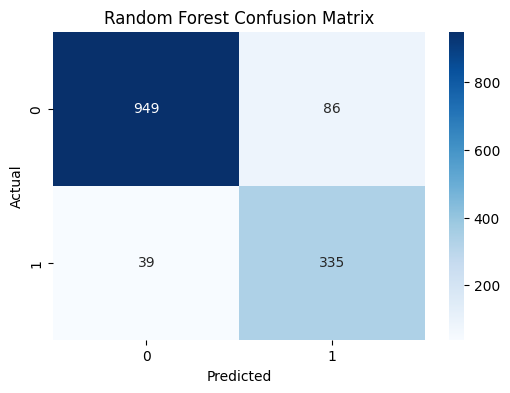

In [19]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### 6-2. 변수 중요도 확인

In [20]:
#변수 중요도 확인
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(20)


,feature,importance
1148,SatisfactionBand_Low,0.152141
10,SatisfactionScore,0.141087
33,Contract_Two Year,0.059567
19,ChargeToMonthlyRatio,0.046830
1152,ContractRiskLevel_Low Risk,0.045606
4,TenureInMonths,0.039260
16,TenureYearGroup,0.033665
30,InternetType_Fiber Optic,0.031458
3,Dependents,0.030589
17,IsLongTermCustomer,0.029345


/tmp/ipykernel_10545/1175787415.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


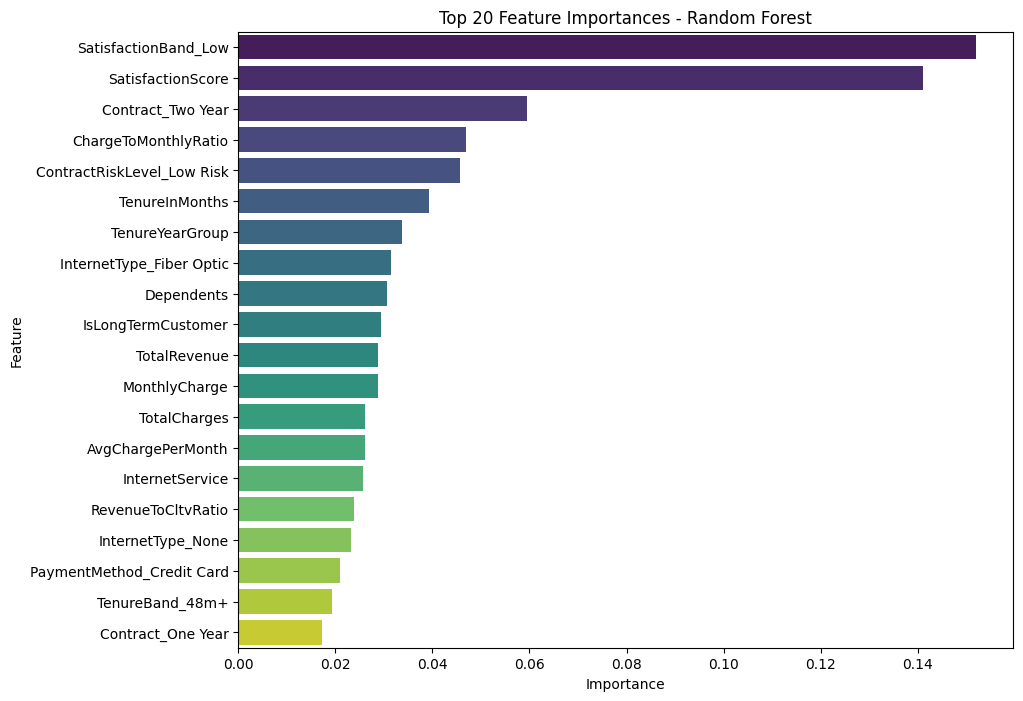

In [21]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(20),
    x="importance",
    y="feature",
    palette="viridis"
)
plt.title("Top 20 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## 7. 모델 학습 — XGBoost (전체 피처)

> Random Forest와 동일한 데이터로 XGBoost를 학습해 성능을 비교합니다.

In [22]:
#XGBoost도 같이 비교하고 싶으면 이것까지 추가하면 됩니다.
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost F1-score:", f1_score(y_test, xgb_pred))
print("XGBoost ROC-AUC :", roc_auc_score(y_test, xgb_pred_proba))
print()
print(classification_report(y_test, xgb_pred))


XGBoost F1-score: 0.9195088676671214
XGBoost ROC-AUC : 0.9904208323645665

              precision    recall  f1-score   support

         0.0       0.96      0.98      0.97      1035
         1.0       0.94      0.90      0.92       374

    accuracy                           0.96      1409
   macro avg       0.95      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409



### 7-1. 변수 중요도 확인

/tmp/ipykernel_10545/2497187919.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


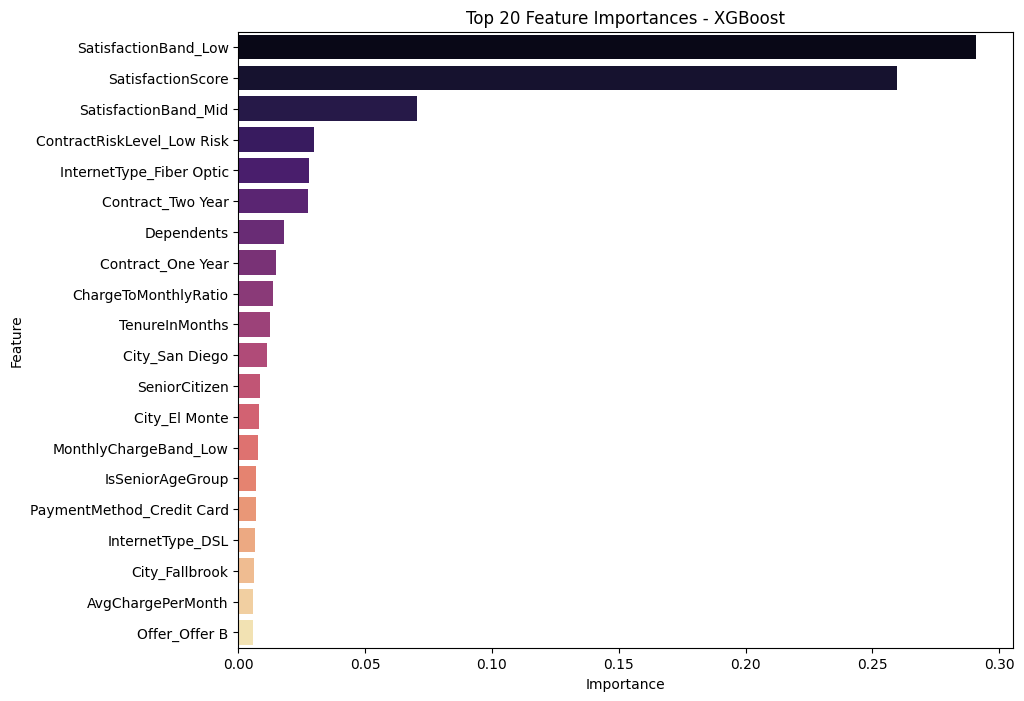

In [23]:
xgb_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=xgb_importance_df.head(20),
    x="importance",
    y="feature",
    palette="magma"
)
plt.title("Top 20 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## 8. 피처 선택 (Feature Selection) — XGBoost

In [24]:
# 피처 재설정
selected_cols = [
    "Age",
    "SeniorCitizen",
    "Married",
    "Dependents",
    "TenureInMonths",
    "TenureBand",
    "Offer",
    "PhoneService",
    "InternetType",
    "Contract",
    "PaymentMethod",
    "MonthlyCharge",
    "ChargeToMonthlyRatio",
    "AvgChargePerMonth",
    "PopulationBand",
    "RevenueToCltvRatio",
    "ChurnValue"
]

df_fs = df[selected_cols].copy()


In [25]:
#숫자형/범주형 결측치 처리
target = "ChurnValue"

for col in df_fs.columns:
    if col == target:
        continue
    if df_fs[col].dtype in ["int64", "float64", "int32", "float32"]:
        df_fs[col] = df_fs[col].fillna(df_fs[col].median())
    else:
        df_fs[col] = df_fs[col].fillna("Unknown")


In [26]:
#입력/타깃 분리 후 원핫인코딩
X_fs = df_fs.drop(columns=[target])
y_fs = df_fs[target]

X_fs = pd.get_dummies(X_fs, drop_first=True)

print("Encoded X shape:", X_fs.shape)
print(y_fs.value_counts())


Encoded X shape: (7043, 15827)
ChurnValue
0    5174
1    1869
Name: count, dtype: Int64


In [27]:
# 학습/테스트 분리
X_fs_train, X_fs_test, y_fs_train, y_fs_test = train_test_split(
    X_fs, y_fs,
    test_size=0.2,
    random_state=42,
    stratify=y_fs
)

In [28]:
#XGBoost 재학습
scale_pos_weight_fs = (y_fs_train == 0).sum() / (y_fs_train == 1).sum()

xgb_model_fs = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight_fs
)

xgb_model_fs.fit(X_fs_train, y_fs_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [29]:
#예측 및 성능 평가
xgb_pred_fs = xgb_model_fs.predict(X_fs_test)
xgb_pred_proba_fs = xgb_model_fs.predict_proba(X_fs_test)[:, 1]

print("XGBoost FS F1-score:", f1_score(y_fs_test, xgb_pred_fs))
print("XGBoost FS ROC-AUC :", roc_auc_score(y_fs_test, xgb_pred_proba_fs))
print()
print(classification_report(y_fs_test, xgb_pred_fs))


XGBoost FS F1-score: 0.6970760233918128
XGBoost FS ROC-AUC : 0.8928944173189697

              precision    recall  f1-score   support

         0.0       0.92      0.82      0.87      1035
         1.0       0.62      0.80      0.70       374

    accuracy                           0.82      1409
   macro avg       0.77      0.81      0.78      1409
weighted avg       0.84      0.82      0.82      1409



### 8-1. 혼동 행렬

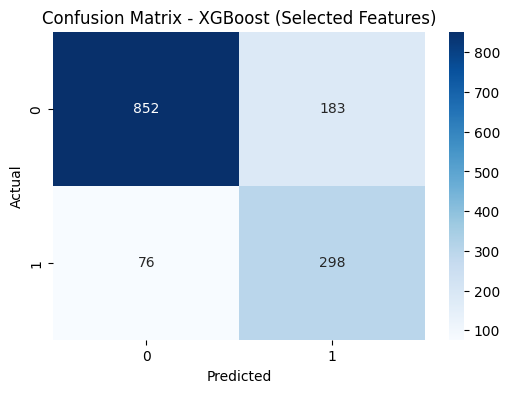

In [30]:
# 혼동 행렬
cm_fs = confusion_matrix(y_fs_test, xgb_pred_fs)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_fs, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - XGBoost (Selected Features)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [31]:
importance_fs = pd.DataFrame({
    "feature": X_fs.columns,
    "importance": xgb_model_fs.feature_importances_
}).sort_values("importance", ascending=False)

importance_fs.head(20)


,feature,importance
20,Contract_Two Year,0.132503
19,Contract_One Year,0.050370
3,Dependents,0.022564
1,SeniorCitizen,0.018274
17,InternetType_Fiber Optic,0.017737
18,InternetType_None,0.016366
21,PaymentMethod_Credit Card,0.009083
9,TenureBand_48m+,0.007926
4,TenureInMonths,0.007918
12,Offer_Offer B,0.007341


### 8-2. 과적합 점검

In [32]:
# 과적합 간단 점검
train_pred_fs = xgb_model_fs.predict(X_fs_train)
train_pred_proba_fs = xgb_model_fs.predict_proba(X_fs_train)[:, 1]

print("Train F1:", f1_score(y_fs_train, train_pred_fs))
print("Test F1 :", f1_score(y_fs_test, xgb_pred_fs))
print("Train ROC-AUC:", roc_auc_score(y_fs_train, train_pred_proba_fs))
print("Test ROC-AUC :", roc_auc_score(y_fs_test, xgb_pred_proba_fs))


Train F1: 0.761769710720363
Test F1 : 0.6970760233918128
Train ROC-AUC: 0.937742301187578
Test ROC-AUC : 0.8928944173189697


## 9. 민감 변수 제거 실험 — XGBoost v2

In [33]:
# SatisfactionScore, SatisfactionBand 제외 버전 재학습
drop_cols_v2 = [
    "CustomerID",
    "ChurnLabel",
    "ChurnCategory",
    "ChurnReason",
    "CustomerStatus",
    "ChurnScore",
    "SatisfactionScore",
    "SatisfactionBand"
]

model_df_v2 = df.drop(columns=[col for col in drop_cols_v2 if col in df.columns]).copy()

for col in model_df_v2.columns:
    if col == "ChurnValue":
        continue
    if model_df_v2[col].dtype in ["int64", "float64", "int32", "float32"]:
        model_df_v2[col] = model_df_v2[col].fillna(model_df_v2[col].median())
    else:
        model_df_v2[col] = model_df_v2[col].fillna("Unknown")

X2 = model_df_v2.drop(columns=["ChurnValue"])
y2 = model_df_v2["ChurnValue"]

X2 = pd.get_dummies(X2, drop_first=True)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

scale_pos_weight_2 = (y2_train == 0).sum() / (y2_train == 1).sum()

xgb_model_v2 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight_2
)

xgb_model_v2.fit(X2_train, y2_train)
xgb_pred_v2 = xgb_model_v2.predict(X2_test)
xgb_pred_proba_v2 = xgb_model_v2.predict_proba(X2_test)[:, 1]

print("XGBoost v2 F1-score:", f1_score(y2_test, xgb_pred_v2))
print("XGBoost v2 ROC-AUC :", roc_auc_score(y2_test, xgb_pred_proba_v2))
print()
print(classification_report(y2_test, xgb_pred_v2))


XGBoost v2 F1-score: 0.6916565900846433
XGBoost v2 ROC-AUC : 0.89326254876127

              precision    recall  f1-score   support

         0.0       0.91      0.84      0.87      1035
         1.0       0.63      0.76      0.69       374

    accuracy                           0.82      1409
   macro avg       0.77      0.80      0.78      1409
weighted avg       0.83      0.82      0.82      1409



### 9-1. Train / Test 성능 비교

In [34]:
train_pred_v2 = xgb_model_v2.predict(X2_train)
train_pred_proba_v2 = xgb_model_v2.predict_proba(X2_train)[:, 1]

test_pred_v2 = xgb_model_v2.predict(X2_test)
test_pred_proba_v2 = xgb_model_v2.predict_proba(X2_test)[:, 1]

print("=== Train Performance ===")
print("Train F1:", f1_score(y2_train, train_pred_v2))
print("Train ROC-AUC:", roc_auc_score(y2_train, train_pred_proba_v2))

print("\n=== Test Performance ===")
print("Test F1:", f1_score(y2_test, test_pred_v2))
print("Test ROC-AUC:", roc_auc_score(y2_test, test_pred_proba_v2))


=== Train Performance ===
Train F1: 0.8472588683670478
Train ROC-AUC: 0.9772327990297044

=== Test Performance ===
Test F1: 0.6916565900846433
Test ROC-AUC: 0.89326254876127


### 9-2. Stratified K-Fold 교차 검증

> 3-Fold CV로 모델 안정성을 검증합니다.

In [35]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
import numpy as np

In [36]:
xgb_cv_v2 = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=(y2 == 0).sum() / (y2 == 1).sum()
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_results = cross_validate(
    xgb_cv_v2,
    X2,
    y2,
    cv=cv,
    scoring={"f1": "f1", "roc_auc": "roc_auc"},
    n_jobs=-1
)

print("CV F1 scores:", cv_results["test_f1"])
print("Mean CV F1:", np.mean(cv_results["test_f1"]))
print("Std CV F1:", np.std(cv_results["test_f1"]))

print("\nCV ROC-AUC scores:", cv_results["test_roc_auc"])
print("Mean CV ROC-AUC:", np.mean(cv_results["test_roc_auc"]))
print("Std CV ROC-AUC:", np.std(cv_results["test_roc_auc"]))

CV F1 scores: [0.69125683 0.67939973 0.689993  ]
Mean CV F1: 0.686883186616389
Std CV F1: 0.005316699466386087

CV ROC-AUC scores: [0.89742108 0.88473539 0.88705109]
Mean CV ROC-AUC: 0.8897358528022042
Std CV ROC-AUC: 0.005515896549033237


### 9-3. 변수 중요도 확인

In [37]:
#마지막으로 중요 변수도 다시 확인하세요.
importance_v2 = pd.DataFrame({
    "feature": X2.columns,
    "importance": xgb_model_v2.feature_importances_
}).sort_values("importance", ascending=False)

importance_v2.head(20)



,feature,importance
30458,ContractRiskLevel_Low Risk,0.107368
26,Contract_Two Year,0.106102
30459,ContractRiskLevel_Medium Risk,0.102024
25,Contract_One Year,0.037859
1,SeniorCitizen,0.019143
3,Dependents,0.018270
23,InternetType_Fiber Optic,0.014459
6,InternetService,0.011806
24,InternetType_None,0.010355
27,PaymentMethod_Credit Card,0.008493


/tmp/ipykernel_10545/2859088950.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


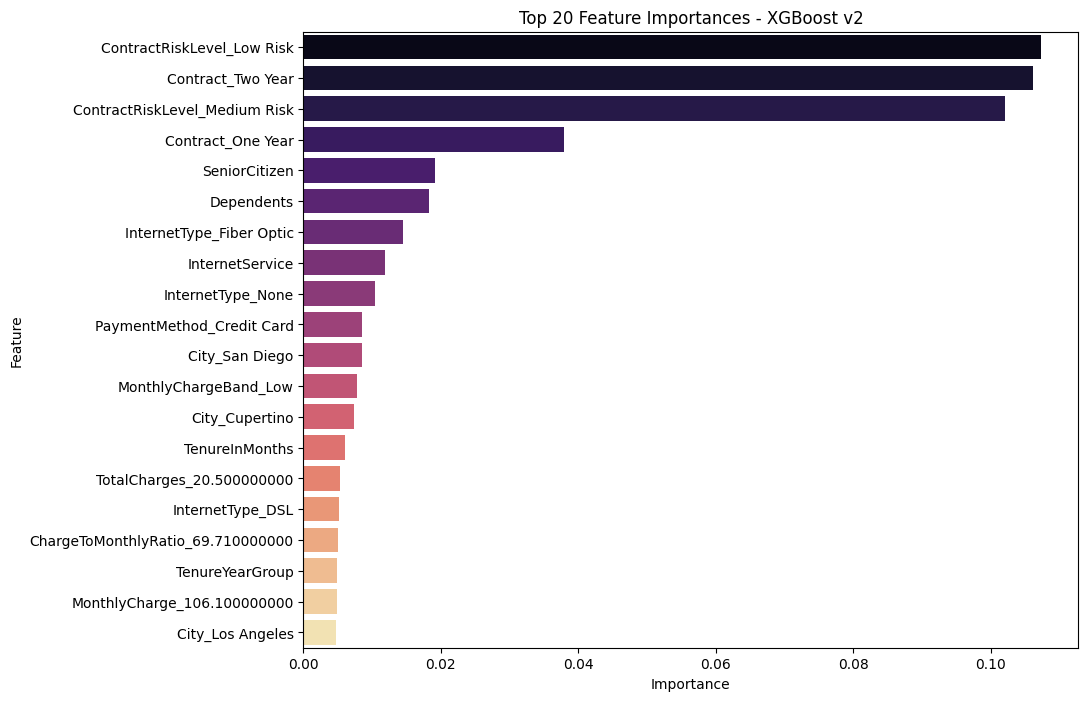

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_v2.head(20),
    x="importance",
    y="feature",
    palette="magma"
)
plt.title("Top 20 Feature Importances - XGBoost v2")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## 10. 차원 축소 — PCA 적용

In [39]:
selected_cols = [
    "Age",
    "SeniorCitizen",
    "Married",
    "Dependents",
    "TenureInMonths",
    "TenureBand",
    "Offer",
    "PhoneService",
    "InternetType",
    "Contract",
    "PaymentMethod",
    "MonthlyCharge",
    "ChargeToMonthlyRatio",
    "AvgChargePerMonth",
    "PopulationBand",
    "RevenueToCltvRatio",
    "ChurnValue"
]

df_pca = df[selected_cols].copy()


In [40]:
#숫자형 칼럼 명시
numeric_object_cols = [
    "MonthlyCharge",
    "ChargeToMonthlyRatio",
    "AvgChargePerMonth",
    "RevenueToCltvRatio"
]

#숫자형 강제 변환
for col in numeric_object_cols:
    df_pca[col] = pd.to_numeric(df_pca[col], errors="coerce")



In [41]:
# 불리언 정리
bool_cols = [
    "SeniorCitizen",
    "Married",
    "Dependents",
    "PhoneService"
]

for col in bool_cols:
    df_pca[col] = df_pca[col].astype("int")


In [42]:
#결측치 처리
numeric_cols = [
    "Age",
    "TenureInMonths",
    "MonthlyCharge",
    "ChargeToMonthlyRatio",
    "AvgChargePerMonth",
    "RevenueToCltvRatio"
]

categorical_cols = [
    "TenureBand",
    "Offer",
    "InternetType",
    "Contract",
    "PaymentMethod",
    "PopulationBand"
]

target = "ChurnValue"

for col in numeric_cols + bool_cols:
    df_pca[col] = df_pca[col].fillna(df_pca[col].median())

for col in categorical_cols:
    df_pca[col] = df_pca[col].fillna("Unknown")

In [43]:
# 원핫인코딩
X_pca_base = df_pca.drop(columns=[target])
y_pca = df_pca[target]

X_pca_base = pd.get_dummies(X_pca_base, drop_first=True)

print("Before PCA shape:", X_pca_base.shape)

Before PCA shape: (7043, 29)


In [44]:
# 학습/테스트 분리
X_train_base, X_test_base, y_train_pca, y_test_pca = train_test_split(
    X_pca_base,
    y_pca,
    test_size=0.2,
    random_state=42,
    stratify=y_pca
)

In [45]:
#표준화 후 PCA 적용
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_base)
X_test_scaled = scaler.transform(X_test_base)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("After PCA shape:", X_train_pca.shape)
print("Explained variance ratio sum:", pca.explained_variance_ratio_.sum())


After PCA shape: (5634, 19)
Explained variance ratio sum: 0.9532497903290315


### 10-1. PCA 기반 XGBoost 학습 및 평가

In [46]:
#XGBoost 적용
scale_pos_weight_pca = (y_train_pca == 0).sum() / (y_train_pca == 1).sum()

xgb_model_pca = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight_pca
)

xgb_model_pca.fit(X_train_pca, y_train_pca)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [47]:
# 성능 평가
xgb_pred_pca = xgb_model_pca.predict(X_test_pca)
xgb_pred_proba_pca = xgb_model_pca.predict_proba(X_test_pca)[:, 1]

print("XGBoost PCA F1-score:", f1_score(y_test_pca, xgb_pred_pca))
print("XGBoost PCA ROC-AUC :", roc_auc_score(y_test_pca, xgb_pred_proba_pca))
print()
print(classification_report(y_test_pca, xgb_pred_pca))

XGBoost PCA F1-score: 0.6584158415841584
XGBoost PCA ROC-AUC : 0.8750923557828928

              precision    recall  f1-score   support

         0.0       0.89      0.84      0.86      1035
         1.0       0.61      0.71      0.66       374

    accuracy                           0.80      1409
   macro avg       0.75      0.77      0.76      1409
weighted avg       0.82      0.80      0.81      1409



In [48]:
#train/test 비교로 과적합 확인
train_pred_pca = xgb_model_pca.predict(X_train_pca)
train_pred_proba_pca = xgb_model_pca.predict_proba(X_train_pca)[:, 1]

print("Train F1:", f1_score(y_train_pca, train_pred_pca))
print("Test F1 :", f1_score(y_test_pca, xgb_pred_pca))
print("Train ROC-AUC:", roc_auc_score(y_train_pca, train_pred_proba_pca))
print("Test ROC-AUC :", roc_auc_score(y_test_pca, xgb_pred_proba_pca))


Train F1: 0.892372625866747
Test F1 : 0.6584158415841584
Train ROC-AUC: 0.9899916852583428
Test ROC-AUC : 0.8750923557828928


In [49]:
# PCA 컴포넌트 개수 확인
print("Number of PCA components:", pca.n_components_)

Number of PCA components: 19


## 11. 클래스 불균형 처리 — SMOTE 적용

> 소수 클래스(이탈 고객)를 오버샘플링해 학습 데이터 불균형을 해소합니다.

In [50]:
from imblearn.over_sampling import SMOTE

In [51]:
# 선별 피처 기반 데이터
# (선별 피처 기반 전처리는 섹션 8과 동일)
selected_cols = [
    "Age",
    "SeniorCitizen",
    "Married",
    "Dependents",
    "TenureInMonths",
    "TenureBand",
    "Offer",
    "PhoneService",
    "InternetType",
    "Contract",
    "PaymentMethod",
    "MonthlyCharge",
    "ChargeToMonthlyRatio",
    "AvgChargePerMonth",
    "PopulationBand",
    "RevenueToCltvRatio",
    "ChurnValue"
]

df_fs = df[selected_cols].copy()


In [52]:
#숫자/불리언/범주형 정리
numeric_object_cols = [
    "MonthlyCharge",
    "ChargeToMonthlyRatio",
    "AvgChargePerMonth",
    "RevenueToCltvRatio"
]

for col in numeric_object_cols:
    df_fs[col] = pd.to_numeric(df_fs[col], errors="coerce")

df_fs["Age"] = pd.to_numeric(df_fs["Age"], errors="coerce").astype("float64")
df_fs["TenureInMonths"] = pd.to_numeric(df_fs["TenureInMonths"], errors="coerce").astype("float64")
df_fs["ChurnValue"] = pd.to_numeric(df_fs["ChurnValue"], errors="coerce").astype("int64")

bool_cols = ["SeniorCitizen", "Married", "Dependents", "PhoneService"]
for col in bool_cols:
    df_fs[col] = df_fs[col].astype("int64")



In [53]:
#결측치 처리
numeric_cols = [
    "Age",
    "TenureInMonths",
    "MonthlyCharge",
    "ChargeToMonthlyRatio",
    "AvgChargePerMonth",
    "RevenueToCltvRatio"
]

categorical_cols = [
    "TenureBand",
    "Offer",
    "InternetType",
    "Contract",
    "PaymentMethod",
    "PopulationBand"
]

for col in numeric_cols + bool_cols:
    df_fs[col] = df_fs[col].fillna(df_fs[col].median())

for col in categorical_cols:
    df_fs[col] = df_fs[col].fillna("Unknown")


In [54]:
#원핫인코딩
X_fs = df_fs.drop(columns=["ChurnValue"])
y_fs = df_fs["ChurnValue"]

X_fs = pd.get_dummies(X_fs, drop_first=True)

print("X_fs shape:", X_fs.shape)
print(y_fs.value_counts())


X_fs shape: (7043, 29)
ChurnValue
0    5174
1    1869
Name: count, dtype: int64


In [55]:
#학습/평가 분리
X_fs_train, X_fs_test, y_fs_train, y_fs_test = train_test_split(
    X_fs, y_fs,
    test_size=0.2,
    random_state=42,
    stratify=y_fs
)


In [56]:
#기준 분포 확인
print("Before resampling:")
print(y_fs_train.value_counts())


Before resampling:
ChurnValue
0    4139
1    1495
Name: count, dtype: int64


In [57]:
#SMOTE 적용
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_fs_train, y_fs_train)

print("After SMOTE:")
print(pd.Series(y_train_smote).value_counts())


After SMOTE:
ChurnValue
0    4139
1    4139
Name: count, dtype: int64


In [58]:
xgb_smote = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_smote.fit(X_train_smote, y_train_smote)

pred_smote = xgb_smote.predict(X_fs_test)
pred_proba_smote = xgb_smote.predict_proba(X_fs_test)[:, 1]

print("SMOTE XGBoost F1-score:", f1_score(y_fs_test, pred_smote))
print("SMOTE XGBoost ROC-AUC :", roc_auc_score(y_fs_test, pred_proba_smote))
print()
print(classification_report(y_fs_test, pred_smote))


SMOTE XGBoost F1-score: 0.6624203821656051
SMOTE XGBoost ROC-AUC : 0.879511224779767

              precision    recall  f1-score   support

           0       0.89      0.85      0.87      1035
           1       0.63      0.70      0.66       374

    accuracy                           0.81      1409
   macro avg       0.76      0.77      0.77      1409
weighted avg       0.82      0.81      0.81      1409



## 12. 이탈 전 증상 분석

> 예측 확률 기반 고위험 고객군을 추출하고, 이탈 전 행동 패턴을 요약합니다.

12-1. 최종 모델 재학습 및 예측 확률 생성

In [59]:
#칼럼 정상화
selected_cols = [
    "Age",
    "SeniorCitizen",
    "Married",
    "Dependents",
    "TenureInMonths",
    "TenureBand",
    "Offer",
    "PhoneService",
    "InternetType",
    "Contract",
    "PaymentMethod",
    "MonthlyCharge",
    "ChargeToMonthlyRatio",
    "AvgChargePerMonth",
    "PopulationBand",
    "RevenueToCltvRatio",
    "ChurnValue"
]

df_fs = df[selected_cols].copy()

In [60]:
numeric_object_cols = [
    "MonthlyCharge",
    "ChargeToMonthlyRatio",
    "AvgChargePerMonth",
    "RevenueToCltvRatio"
]

for col in numeric_object_cols:
    df_fs[col] = pd.to_numeric(df_fs[col], errors="coerce")

bool_cols = ["SeniorCitizen", "Married", "Dependents", "PhoneService"]
for col in bool_cols:
    df_fs[col] = df_fs[col].astype(int)

numeric_cols = [
    "Age",
    "TenureInMonths",
    "MonthlyCharge",
    "ChargeToMonthlyRatio",
    "AvgChargePerMonth",
    "RevenueToCltvRatio"
]

categorical_cols = [
    "TenureBand",
    "Offer",
    "InternetType",
    "Contract",
    "PaymentMethod",
    "PopulationBand"
]

for col in numeric_cols + bool_cols:
    df_fs[col] = df_fs[col].fillna(df_fs[col].median())

for col in categorical_cols:
    df_fs[col] = df_fs[col].fillna("Unknown")

In [61]:
X_fs_raw = df_fs.drop(columns=["ChurnValue"]).copy()
y_fs = df_fs["ChurnValue"].astype(int)

X_fs = pd.get_dummies(X_fs_raw, drop_first=True).astype("float64")

In [62]:
X_fs_train, X_fs_test, y_fs_train, y_fs_test = train_test_split(
    X_fs, y_fs,
    test_size=0.2,
    random_state=42,
    stratify=y_fs
)

scale_pos_weight_fs = (y_fs_train == 0).sum() / (y_fs_train == 1).sum()

xgb_model_fs = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight_fs
)

xgb_model_fs.fit(X_fs_train, y_fs_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [63]:
# 테스트셋 예측확률 생성
pred_proba_fs = xgb_model_fs.predict_proba(X_fs_test)[:, 1]
pred_label_fs = xgb_model_fs.predict(X_fs_test)

result_fs = X_fs_test.copy()
result_fs["actual_churn"] = y_fs_test.values
result_fs["pred_churn"] = pred_label_fs
result_fs["pred_proba"] = pred_proba_fs

result_fs.head()

,Age,SeniorCitizen,Married,Dependents,TenureInMonths,PhoneService,MonthlyCharge,ChargeToMonthlyRatio,AvgChargePerMonth,RevenueToCltvRatio,...,InternetType_None,Contract_One Year,Contract_Two Year,PaymentMethod_Credit Card,PaymentMethod_Mailed Check,PopulationBand_Low,PopulationBand_Mid,actual_churn,pred_churn,pred_proba
1963,62.0,0.0,1.0,1.0,8.0,1.0,54.65,8.82,60.28,0.1412,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0,0,0.211480
3526,72.0,1.0,1.0,0.0,71.0,1.0,82.70,70.51,82.13,1.6694,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0,0,0.008626
3492,46.0,0.0,1.0,1.0,61.0,0.0,61.45,61.04,61.49,0.7409,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0,0,0.001493
5162,49.0,0.0,1.0,1.0,59.0,1.0,99.50,58.91,99.35,1.8080,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0,0,0.005249
4642,79.0,1.0,0.0,0.0,21.0,1.0,20.50,20.95,20.45,0.1591,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0,0,0.056724


In [64]:
original_test_fs = df_fs.loc[X_fs_test.index].copy()
original_test_fs["actual_churn"] = y_fs_test
original_test_fs["pred_churn"] = pred_label_fs
original_test_fs["pred_proba"] = pred_proba_fs

original_test_fs.head()


,Age,SeniorCitizen,Married,Dependents,TenureInMonths,TenureBand,Offer,PhoneService,InternetType,Contract,PaymentMethod,MonthlyCharge,ChargeToMonthlyRatio,AvgChargePerMonth,PopulationBand,RevenueToCltvRatio,ChurnValue,actual_churn,pred_churn,pred_proba
1963,62,0,1,1,8,6-11m,Offer E,1,DSL,Month-to-Month,Credit Card,54.65,8.82,60.28,Low,0.1412,0,0,0,0.211480
3526,72,1,1,0,71,48m+,Offer A,1,DSL,Two Year,Bank Withdrawal,82.70,70.51,82.13,Low,1.6694,0,0,0,0.008626
3492,46,0,1,1,61,48m+,Offer B,0,DSL,Two Year,Bank Withdrawal,61.45,61.04,61.49,Low,0.7409,0,0,0,0.001493
5162,49,0,1,1,59,48m+,None,1,Fiber Optic,Two Year,Credit Card,99.50,58.91,99.35,Mid,1.8080,0,0,0,0.005249
4642,79,1,0,0,21,12-23m,None,1,None,One Year,Bank Withdrawal,20.50,20.95,20.45,Low,0.1591,0,0,0,0.056724


### 12-2. 고위험 고객 추출 (예측 확률 ≥ 0.7)

In [65]:
#고위험 고객군 확인
high_risk_fs = original_test_fs[original_test_fs["pred_proba"] >= 0.7].copy()
high_risk_fs[["pred_proba", "actual_churn", "pred_churn"]].head(20)


,pred_proba,actual_churn,pred_churn
430,0.875017,1,1
3410,0.800806,0,1
186,0.961561,1,1
1915,0.740379,1,1
1495,0.847563,1,1
89,0.911381,1,1
240,0.736517,1,1
223,0.913017,1,1
134,0.792731,1,1
1334,0.710269,1,1


### 12-3. 범주형 피처별 이탈 전 증상 비교

> 전체 분포 vs 고위험군 분포를 비교해 이탈 신호 피처를 확인합니다.

In [66]:
#이탈전 증상 요약
for col in ["Contract", "TenureBand", "InternetType", "PaymentMethod", "PopulationBand"]:
    print(f"\n===== {col} =====")
    print("Overall")
    print(original_test_fs[col].value_counts(normalize=True).round(3))
    print("\nHigh Risk")
    print(high_risk_fs[col].value_counts(normalize=True).round(3))



===== Contract =====
Overall
Contract
Month-to-Month    0.505
Two Year          0.277
One Year          0.218
Name: proportion, dtype: float64

High Risk
Contract
Month-to-Month    0.987
One Year          0.013
Name: proportion, dtype: float64

===== TenureBand =====
Overall
TenureBand
48m+      0.326
0-5m      0.199
12-23m    0.143
24-35m    0.138
36-47m    0.111
6-11m     0.083
Name: proportion, dtype: float64

High Risk
TenureBand
0-5m      0.495
12-23m    0.149
6-11m     0.142
24-35m    0.092
36-47m    0.063
48m+      0.059
Name: proportion, dtype: float64

===== InternetType =====
Overall
InternetType
Fiber Optic    0.407
DSL            0.257
None           0.215
Cable          0.121
Name: proportion, dtype: float64

High Risk
InternetType
Fiber Optic    0.706
DSL            0.139
Cable          0.125
None           0.030
Name: proportion, dtype: float64

===== PaymentMethod =====
Overall
PaymentMethod
Bank Withdrawal    0.566
Credit Card        0.389
Mailed Check       0.045
Nam

### 12-4. 이탈 위험 세그먼트 룰 도출

> Contract × TenureBand × InternetType 조합별 실제 이탈률과 평균 위험도를 산출합니다.

In [67]:
symptom_rules = (
    original_test_fs.groupby(["Contract", "TenureBand", "InternetType"])
    .agg(
        customer_cnt=("pred_proba", "count"),
        avg_risk=("pred_proba", "mean"),
        actual_churn_rate=("actual_churn", "mean")
    )
    .reset_index()
    .query("customer_cnt >= 10")
    .sort_values(["actual_churn_rate", "avg_risk"], ascending=False)
)

symptom_rules.head(15)


,Contract,TenureBand,InternetType,customer_cnt,avg_risk,actual_churn_rate
2,Month-to-Month,0-5m,Fiber Optic,96,0.873070,0.739583
21,Month-to-Month,6-11m,Fiber Optic,41,0.827280,0.707317
0,Month-to-Month,0-5m,Cable,42,0.709264,0.642857
1,Month-to-Month,0-5m,DSL,70,0.590445,0.614286
10,Month-to-Month,24-35m,Fiber Optic,60,0.620158,0.583333
14,Month-to-Month,36-47m,Fiber Optic,43,0.556055,0.534884
6,Month-to-Month,12-23m,Fiber Optic,64,0.668096,0.531250
4,Month-to-Month,12-23m,Cable,14,0.546889,0.428571
20,Month-to-Month,6-11m,DSL,27,0.398948,0.407407
13,Month-to-Month,36-47m,DSL,11,0.335288,0.363636


## 13. SHAP 분석: XGBoost FS 모델 기준

In [68]:
!pip install -q shap


In [69]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [70]:
explainer_fs = shap.TreeExplainer(xgb_model_fs)
shap_values_fs = explainer_fs.shap_values(X_fs_test)

In [71]:
print(type(shap_values_fs))
print(np.array(shap_values_fs).shape)

<class 'numpy.ndarray'>
(1409, 29)


### 13-1 Summary Plot : 전체 피처 중요도 + 방향

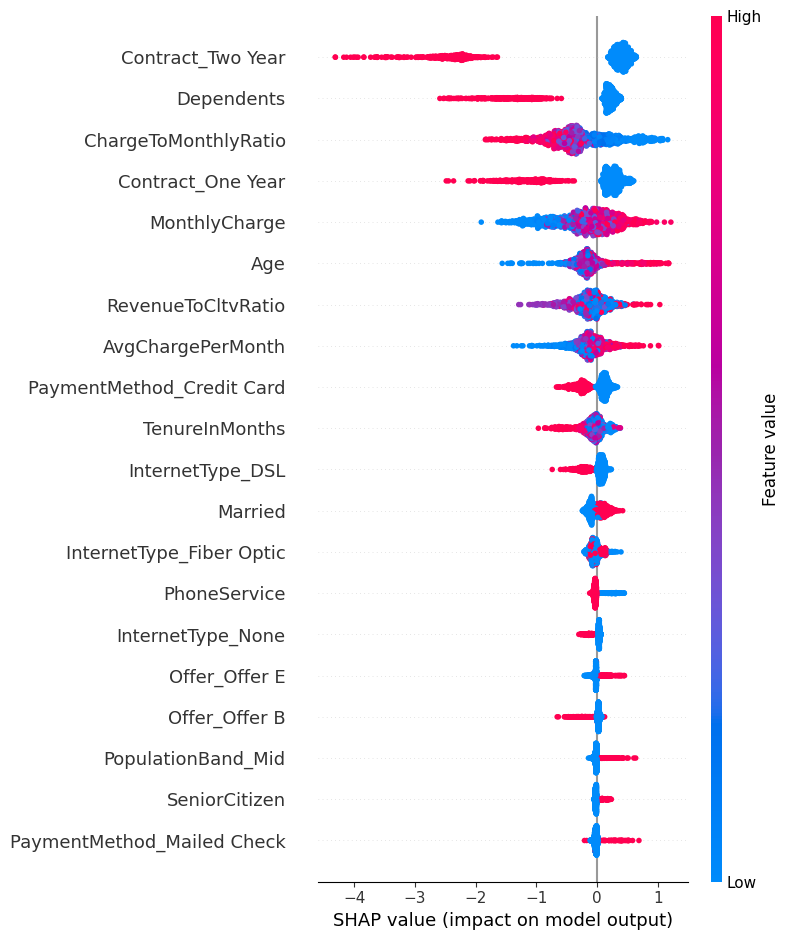

In [72]:
shap.summary_plot(shap_values_fs, X_fs_test, feature_names=X_fs_test.columns)

### 13-2 Bar Plot : 피처 중요도 순위

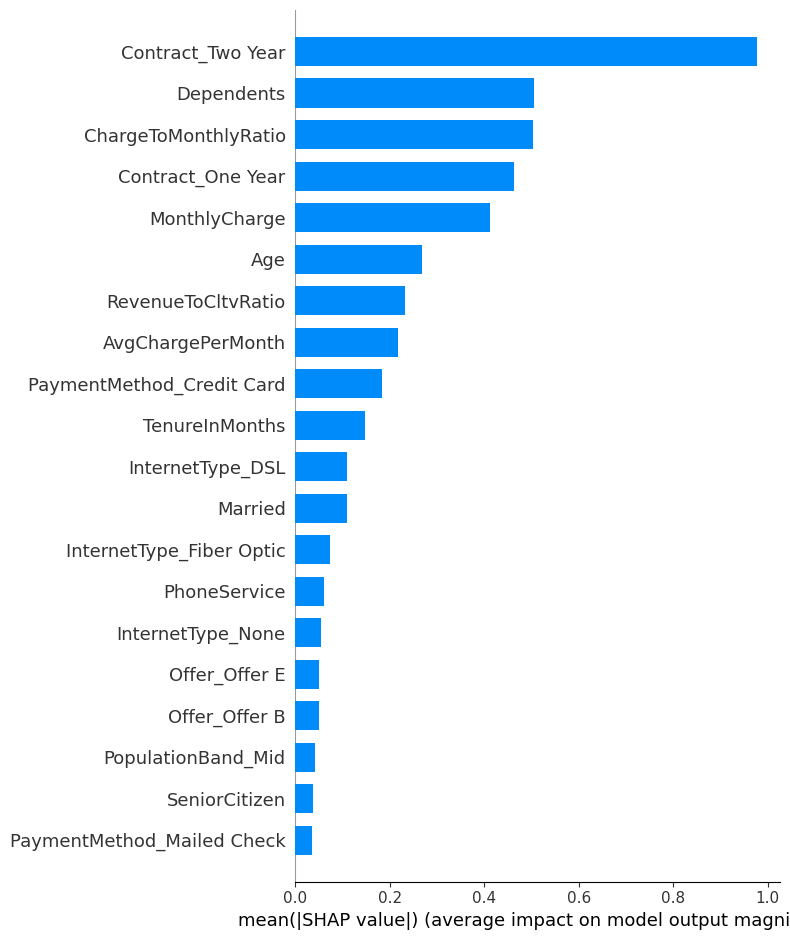

In [73]:
shap.summary_plot(
    shap_values_fs,
    X_fs_test,
    feature_names=X_fs_test.columns,
    plot_type="bar"
)

### 13-3 Force Plot : 개별 고객 1명의 예측 해석

In [74]:
#먼저 한 명 선택
idx = 0

In [75]:
#실제값, 예측값, 이탈 확률 확인
print(f"실제값: {'이탈' if y_fs_test.iloc[idx] == 1 else '유지'}")
print(f"예측값: {'이탈' if xgb_model_fs.predict(X_fs_test.iloc[[idx]])[0] == 1 else '유지'}")
print(f"이탈 확률: {xgb_model_fs.predict_proba(X_fs_test.iloc[[idx]])[0][1]:.3f}")

실제값: 유지
예측값: 유지
이탈 확률: 0.211


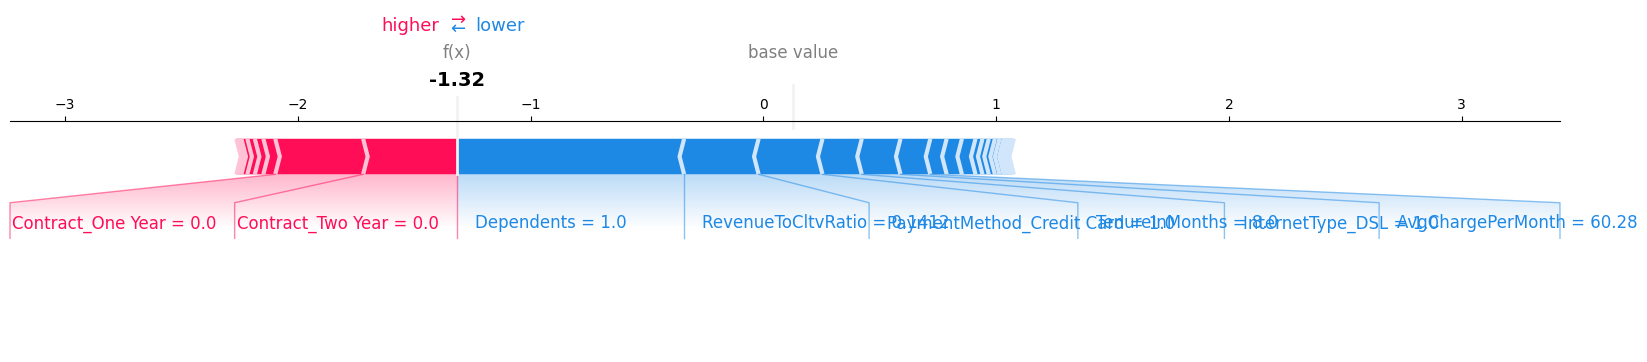

In [76]:
shap.force_plot(
    explainer_fs.expected_value,
    shap_values_fs[idx],
    X_fs_test.iloc[idx],
    matplotlib=True
)
plt.show()

### 13-4 Dependence Plot : 특정 피처가 위험에 미치는 패턴

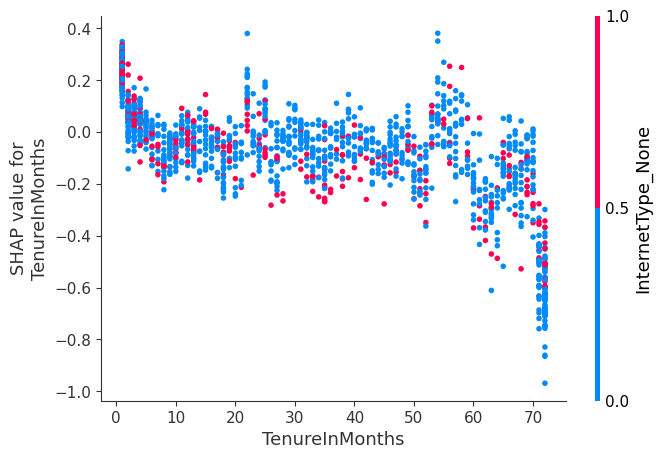

In [77]:
# 가입기간, 요금, 인터넷 유형 확인
shap.dependence_plot("TenureInMonths", shap_values_fs, X_fs_test)

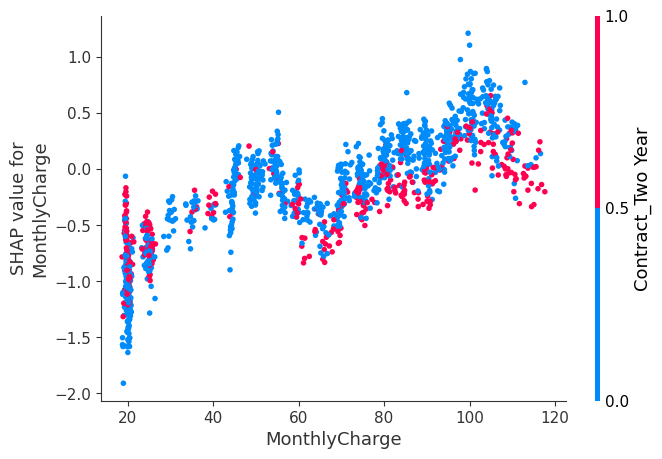

In [78]:
shap.dependence_plot("MonthlyCharge", shap_values_fs, X_fs_test)

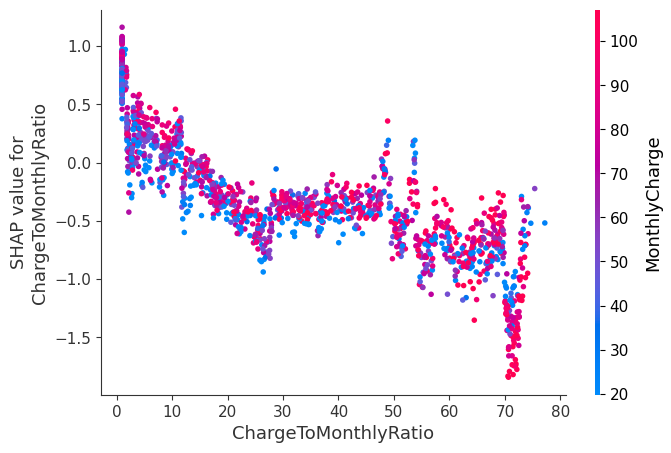

In [79]:
shap.dependence_plot("ChargeToMonthlyRatio", shap_values_fs, X_fs_test)

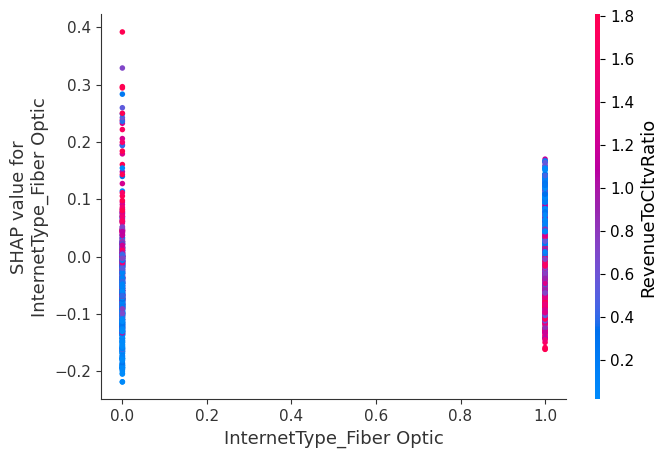

In [80]:
#더미 변수들
shap.dependence_plot("InternetType_Fiber Optic", shap_values_fs, X_fs_test)

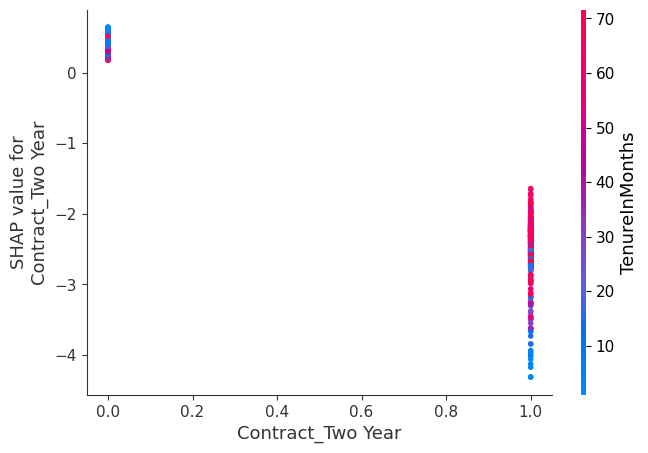

In [81]:
shap.dependence_plot("Contract_Two Year", shap_values_fs, X_fs_test)